# Expected Score Model — Poisson Regression

**Hypothesis:** A Poisson GLM can model team scoring from team-level performance stats (inside-50s, contested possessions, clearances).

**Method:** Aggregate player stats to team-game level. Fit a Poisson GLM (log link) via statsmodels. Compare predicted vs actual scores. Examine which stats drive scoring.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

sns.set_theme(style='whitegrid')
DB = '../data/database/afl_analytics.db'
conn = sqlite3.connect(DB)

In [2]:
# Team-level stats per game from player stats
team_stats = pd.read_sql("""
    SELECT
        f.team_key,
        f.opponent_key,
        f.season_key,
        f.round,
        SUM(f.inside_50s)            AS inside_50s,
        SUM(f.contested_possessions) AS contested_poss,
        SUM(f.clearances)            AS clearances,
        SUM(f.marks_inside_50)       AS marks_inside_50,
        SUM(f.goals)                 AS goals_scored,
        SUM(f.behinds)               AS behinds_scored,
        SUM(f.disposals)             AS disposals,
        SUM(f.tackles)               AS tackles
    FROM fact_player_match_stats f
    WHERE f.inside_50s IS NOT NULL
    GROUP BY f.team_key, f.opponent_key, f.season_key, f.round
""", conn)

# Score from match results to use as ground truth
home_scores = pd.read_sql("""
    SELECT home_team_key AS team_key, season_key, round,
           home_total_score AS actual_score
    FROM fact_match_results
    WHERE home_total_score IS NOT NULL AND is_final = 0
""", conn)

away_scores = pd.read_sql("""
    SELECT away_team_key AS team_key, season_key, round,
           away_total_score AS actual_score
    FROM fact_match_results
    WHERE away_total_score IS NOT NULL AND is_final = 0
""", conn)

actual_scores = pd.concat([home_scores, away_scores])

df = team_stats.merge(actual_scores, on=['team_key','season_key','round'], how='inner')
df = df.dropna(subset=['actual_score','inside_50s','contested_poss','clearances'])
print(f'Rows for modelling: {len(df)}')
print(df[['actual_score','inside_50s','contested_poss','clearances','marks_inside_50']].describe().round(1))

Rows for modelling: 5556
       actual_score  inside_50s  contested_poss  clearances  marks_inside_50
count        5556.0      5556.0          5556.0      5556.0           5556.0
mean           84.2        51.1           137.1        36.8             11.4
std            27.2         8.9            16.4         6.8              4.4
min             0.0        17.0            77.0        16.0              0.0
25%            65.0        45.0           126.0        32.0              8.0
50%            82.0        51.0           136.0        37.0             11.0
75%           102.0        57.0           148.0        41.0             14.0
max           205.0        83.0           213.0        71.0             33.0


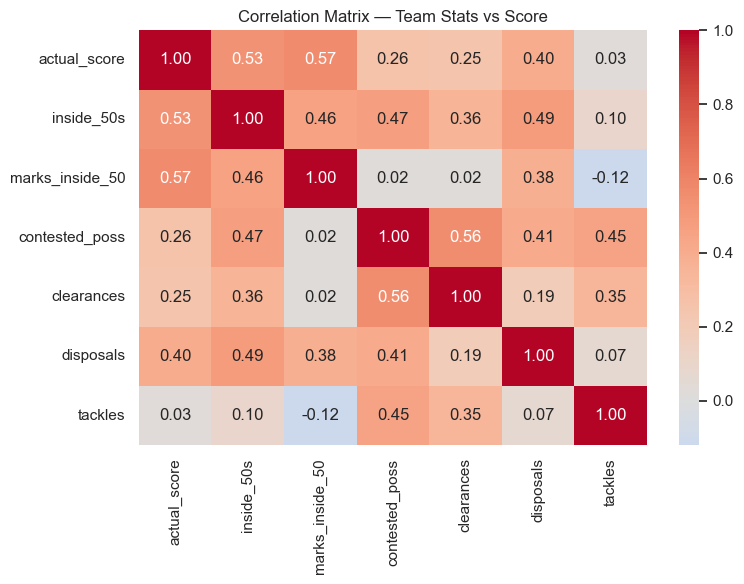

In [3]:
# Correlation heatmap of key stats vs score
corr_cols = ['actual_score','inside_50s','marks_inside_50','contested_poss','clearances','disposals','tackles']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix — Team Stats vs Score')
plt.tight_layout()
plt.show()

In [4]:
# Fit Poisson GLM
features = ['inside_50s','marks_inside_50','contested_poss','clearances']
X = sm.add_constant(df[features])
y = df['actual_score'].astype(int)

poisson_model = sm.GLM(y, X, family=sm.families.Poisson()).fit()
print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           actual_score   No. Observations:                 5556
Model:                            GLM   Df Residuals:                     5551
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -31912.
Date:                Mon, 04 May 2026   Deviance:                       29363.
Time:                        16:55:03   Pearson chi2:                 2.77e+04
No. Iterations:                     4   Pseudo R-squ. (CS):             0.9773
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               3.1719      0.013    2

MAE:         15.78 points
Correlation: 0.6570


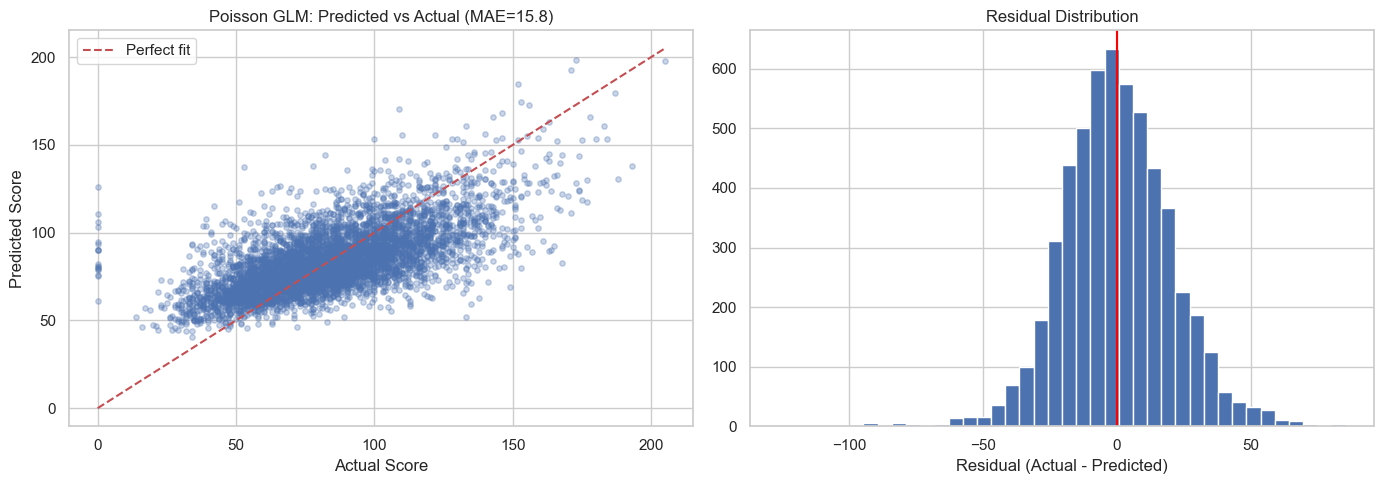

In [5]:
# Predicted vs actual
df['predicted_score'] = poisson_model.predict(X)
mae = mean_absolute_error(df['actual_score'], df['predicted_score'])
corr_pred = df[['actual_score','predicted_score']].corr().iloc[0,1]
print(f'MAE:         {mae:.2f} points')
print(f'Correlation: {corr_pred:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: predicted vs actual
axes[0].scatter(df['actual_score'], df['predicted_score'], alpha=0.3, s=15)
lims = [df['actual_score'].min(), df['actual_score'].max()]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual Score')
axes[0].set_ylabel('Predicted Score')
axes[0].set_title(f'Poisson GLM: Predicted vs Actual (MAE={mae:.1f})')
axes[0].legend()

# Residuals
residuals = df['actual_score'] - df['predicted_score']
axes[1].hist(residuals, bins=40, edgecolor='white')
axes[1].axvline(0, color='red', lw=1.5)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

In [6]:
# Goodness of fit: Pearson chi-squared dispersion test
pearson_chi2 = poisson_model.pearson_chi2
df_resid = poisson_model.df_resid
dispersion = pearson_chi2 / df_resid
print(f'Pearson chi2 / df = {dispersion:.3f}')
if dispersion > 1.5:
    print('Overdispersed — consider Negative Binomial regression as an alternative.')
else:
    print('Dispersion is acceptable for Poisson.')

conn.close()

Pearson chi2 / df = 4.990
Overdispersed — consider Negative Binomial regression as an alternative.
